In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import fastf1
import requests
from time import sleep

In [8]:
# Extracing data using Erast API!!
def fetch_data(url) :
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    return None

def save_season_list():
    url = "http://ergast.com/api/f1/seasons.json?limit=1000"
    data = fetch_data(url)
    if data:
        seasons = pd.json_normalize(data['MRData']['SeasonTable']['Seasons'])
        seasons.to_csv('season_list.csv', index=False)
save_season_list()

def save_race_schedule():
    all_data = []
    for year in range(1950, 2024 + 1):
        url = f"http://ergast.com/api/f1/{year}.json"
        data = fetch_data(url)
        if data:
            races = pd.json_normalize(data['MRData']['RaceTable']['Races'])
            all_data.append(races)
        sleep(1)
    full_data = pd.concat(all_data, ignore_index=True)
    full_data.to_csv('race_schedule.csv', index=False)
save_race_schedule()

def save_race_results():
    all_data = []
    for year in range(1950, 2024 + 1):
        url = f"http://ergast.com/api/f1/{year}/results.json?limit=1000"
        data = fetch_data(url)
        if data:
            results = pd.json_normalize(data['MRData']['RaceTable']['Races'])
            all_data.append(results)
        sleep(1)
    full_data = pd.concat(all_data, ignore_index=True)
    full_data.to_csv('race_results.csv', index=False)
save_race_results()

def save_qualifying_results():
    all_data = []
    for year in range(1950, 2024 + 1):
        url = f"http://ergast.com/api/f1/{year}/qualifying.json?limit=1000"
        data = fetch_data(url)
        if data:
            qualifying = pd.json_normalize(data['MRData']['RaceTable']['Races'])
            all_data.append(qualifying)
        sleep(1)
    full_data = pd.concat(all_data, ignore_index=True)
    full_data.to_csv('qualifying_results.csv', index=False)
save_qualifying_results()

def save_sprint_results():
    all_data = []
    for year in range(2021, 2024 + 1):  
        url = f"http://ergast.com/api/f1/{year}/sprint.json"
        data = fetch_data(url)
        if data:
            sprints = pd.json_normalize(data['MRData']['RaceTable']['Races'])
            all_data.append(sprints)
        sleep(1)
    full_data = pd.concat(all_data, ignore_index=True)
    full_data.to_csv('sprint_results.csv', index=False)
save_sprint_results()

def save_standings():
    all_data = []
    for year in range(1950, 2024 + 1):
        url = f"http://ergast.com/api/f1/{year}/driverStandings.json"
        data = fetch_data(url)
        if data:
            standings = pd.json_normalize(data['MRData']['StandingsTable']['StandingsLists'])
            all_data.append(standings)
        sleep(1)
    full_data = pd.concat(all_data, ignore_index=True)
    full_data.to_csv('driver_standings.csv', index=False)
save_standings()

def save_driver_info():
    url = "http://ergast.com/api/f1/drivers.json?limit=1000"
    data = fetch_data(url)
    if data:
        drivers = pd.json_normalize(data['MRData']['DriverTable']['Drivers'])
        drivers.to_csv('driver_info.csv', index=False)
save_driver_info()

def save_constructor_info():
    url = "http://ergast.com/api/f1/constructors.json?limit=1000"
    data = fetch_data(url)
    if data:
        constructors = pd.json_normalize(data['MRData']['ConstructorTable']['Constructors'])
        constructors.to_csv('constructor_info.csv', index=False)
save_constructor_info()

def save_circuit_info():
    url = "http://ergast.com/api/f1/circuits.json?limit=1000"
    data = fetch_data(url)
    if data:
        circuits = pd.json_normalize(data['MRData']['CircuitTable']['Circuits'])
        circuits.to_csv('circuit_info.csv', index=False)
save_circuit_info()

def save_finishing_status():
    url = "http://ergast.com/api/f1/status.json?limit=1000"
    data = fetch_data(url)
    if data:
        status = pd.json_normalize(data['MRData']['StatusTable']['Status'])
        status.to_csv('finishing_status.csv', index=False)
save_finishing_status()


KeyboardInterrupt: 

In [2]:
fastf1.Cache.enable_cache('/Users/rahulrajagopal/Documents/PBL - RaceWiz AI/F1 data extraction')

In [5]:
race_data = []

for year in range(2018, 2024):  
    for round_number in range(1, 20):  
        try:
            session = fastf1.get_session(year, round_number, 'R')  
            session.load()
            laps = session.laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'AirTemp', 'TrackTemp']]
            laps['Year'] = year
            laps['Round'] = round_number
            race_data.append(laps)
        except Exception as e:
            print(f"Failed to load data for {year} Round {round_number}: {e}")

laps_df = pd.concat(race_data, ignore_index=True)
print(laps_df.head())


core           INFO 	Loading data for Australian Grand Prix - Race [v3.4.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

Failed to load data for 2018 Round 1: "['AirTemp', 'TrackTemp'] not in index"


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Skipping lap alignment (no suit

Failed to load data for 2018 Round 2: "['AirTemp', 'TrackTemp'] not in index"


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

...

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


Failed to load data for 2023 Round 18: Failed to load any schedule data.


logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
logger      WARNING 	Failed to load schedule from F1 API backend!
logger      WARNING 	Failed to load schedule from Ergast API backend!


Failed to load data for 2023 Round 19: Failed to load any schedule data.


ValueError: No objects to concatenate

In [5]:
year = 2024

def save_session_data(year, round_number):
    session = fastf1.get_session(year, round_number, 'R')  
    session.load()
    return session
for round_number in range(1,24): 
       try:
            save_session_data(year, round_number)
       except Exception as e:
            print(f"Skipping {year} Round {round_number} due to: {e}")


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.4.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data f

In [1]:
avg_lap_times = laps_df.groupby('Driver')['LapTime'].mean()
avg_lap_times.plot(kind='bar', title='Average Lap Time by Driver', xlabel='Driver', ylabel='Lap Time (s)')
plt.show()

NameError: name 'laps_df' is not defined

core           INFO 	Loading data for Australian Grand Prix - Race [v3.4.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

Compound
HARD     0 days 00:01:24.942805177
MEDIUM   0 days 00:01:36.212128378
SOFT     0 days 00:01:41.735368421
Name: LapTime, dtype: timedelta64[ns]


<Axes: title={'center': 'Average Lap Times by Tire Compound'}, xlabel='Compound'>

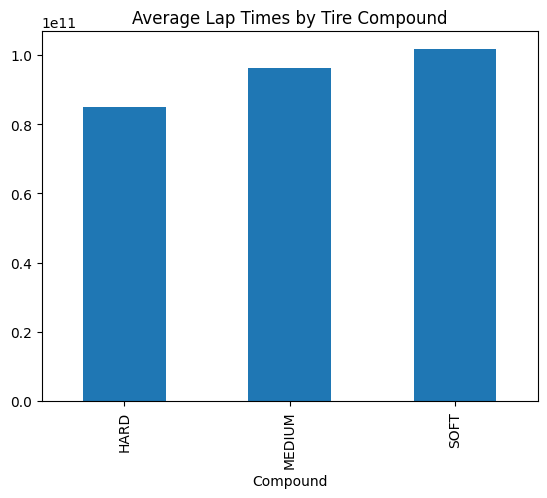

In [3]:
import fastf1 as ff1
import pandas as pd
from fastf1 import plotting

# Load the session data
year = 2023
race = 'Australian Grand Prix'
session = ff1.get_session(year, race, 'R')  # 'R' stands for the race session
session.load()

# Data extraction for tire compounds
laps = session.laps
lap_times = laps[['Driver', 'LapTime', 'Compound']]

# Calculate average lap times for each compound
avg_lap_times = lap_times.groupby('Compound')['LapTime'].mean().sort_values()
print(avg_lap_times)

# Plotting compound vs average lap time
avg_lap_times.plot(kind='bar', title='Average Lap Times by Tire Compound')
